# Bivariate/Multivariate analysis

Studying variable dependency through correlation calculations, independence tests, and tests comparing multiple populations (such as the test of means); visualization (scatter plots on combinations of 2 variables; 3D plots; scatter plots on principal components; non-linear mappings in bi-dimensional space: Sammon, t-SNE, uMap; projections extracted via projection pursuit methodologies - the tourr package in R; conditional boxplots; stacked or overlapped histograms; corrgrams). -- more theory [here](https://edu.info.uaic.ro/data-mining/) and [here](https://www.analyticsvidhya.com/blog/2022/02/a-quick-guide-to-bivariate-analysis-in-python/).

Tha dataset used in our study is the [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction?resource=download).

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind

df = pd.read_csv('./data/heart.csv')

print(df.to_string()) 

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease
0     40   M           ATA        140          289          0     Normal    172              N      0.0       Up             0
1     49   F           NAP        160          180          0     Normal    156              N      1.0     Flat             1
2     37   M           ATA        130          283          0         ST     98              N      0.0       Up             0
3     48   F           ASY        138          214          0     Normal    108              Y      1.5     Flat             1
4     54   M           NAP        150          195          0     Normal    122              N      0.0       Up             0
5     39   M           NAP        120          339          0     Normal    170              N      0.0       Up             0
6     45   F           ATA        130          237          0     Normal    170              N      0.0       U

## We are verifying if the datasets contains any missing data.

isnull() returns a DataFrame of Boolean value where True represents missing data (NaN).

RESULTS -> There is no missing data. All the atributes are filled with data/No missing data.

In [37]:
import ipywidgets as widgets

print("attribute        missing values       data types")

mv = df.isnull()
output1 = mv.count()
output2 = df.dtypes

out1 = widgets.Output()
out2 = widgets.Output()

with out1:
    display(output1)
with out2:
    display(output2)

two_columns = widgets.HBox([out1, out2])
display(two_columns)

attribute        missing values       data types


## Statistical Analysis & Predictive Power

A T-Test (**numeriacal avalues**) is used to compare means between groups to see if the difference is statistically significant. (heart disease and non-heart disease groups)

The differences between environments are most evident at the level of characteristics:
1. T-Test for Oldpeak: p-value = 2.3908e-37
2. T-Test for MaxHR: p-value = 1.1378e-36
3. T-Test for Age: p-value = 3.0080e-18

In [38]:
for col in ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']:
    group0 = df[df['HeartDisease'] == 0][col]
    group1 = df[df['HeartDisease'] == 1][col]
    t_stat, p_val = ttest_ind(group0, group1)
    print(f"T-Test for {col}: p-value = {p_val:.4e}")

T-Test for Age: p-value = 3.0080e-18
T-Test for RestingBP: p-value = 1.0953e-03
T-Test for Cholesterol: p-value = 9.3083e-13
T-Test for MaxHR: p-value = 1.1378e-36
T-Test for Oldpeak: p-value = 2.3908e-37


The Chi-Square test (**categorical values**) is used to determine if there is a significant association between two categorical variables.

All attributes are closely correlated with the target, but among them, the most significant and essential data/attributes are:

1. Chi-Square Test for Sex: p-value = 4.5976e-20 (**How the heart recovers after exercise is critical**)
2. Chi-Square Test for ChestPainType: p-value = 8.0837e-58 (**Only certain chest pains are essential and can highlight a possible cardiac arrest.**)
3. Chi-Square Test for FastingBS: p-value = 1.0573e-15 (**An obvious metric is chest pain during sports training.**)
4. Chi-Square Test for ExerciseAngina: p-value = 2.9078e-50(**between the two sexes we have significant differences in distribution.**)


In [39]:
for col in ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']:
    contingency = pd.crosstab(df[col], df['HeartDisease'])
    chi2, p, _, _ = chi2_contingency(contingency)
    print(f"Chi-Square Test for {col}: p-value = {p:.4e}")

Chi-Square Test for Sex: p-value = 4.5976e-20
Chi-Square Test for ChestPainType: p-value = 8.0837e-58
Chi-Square Test for FastingBS: p-value = 1.0573e-15
Chi-Square Test for RestingECG: p-value = 4.2292e-03
Chi-Square Test for ExerciseAngina: p-value = 2.9078e-50
Chi-Square Test for ST_Slope: p-value = 5.1676e-78


### Conditional Visualizations

Using boxplots we can visualize the discrepancies indicated by the T-tests above. This way we can observe the differences between classes.

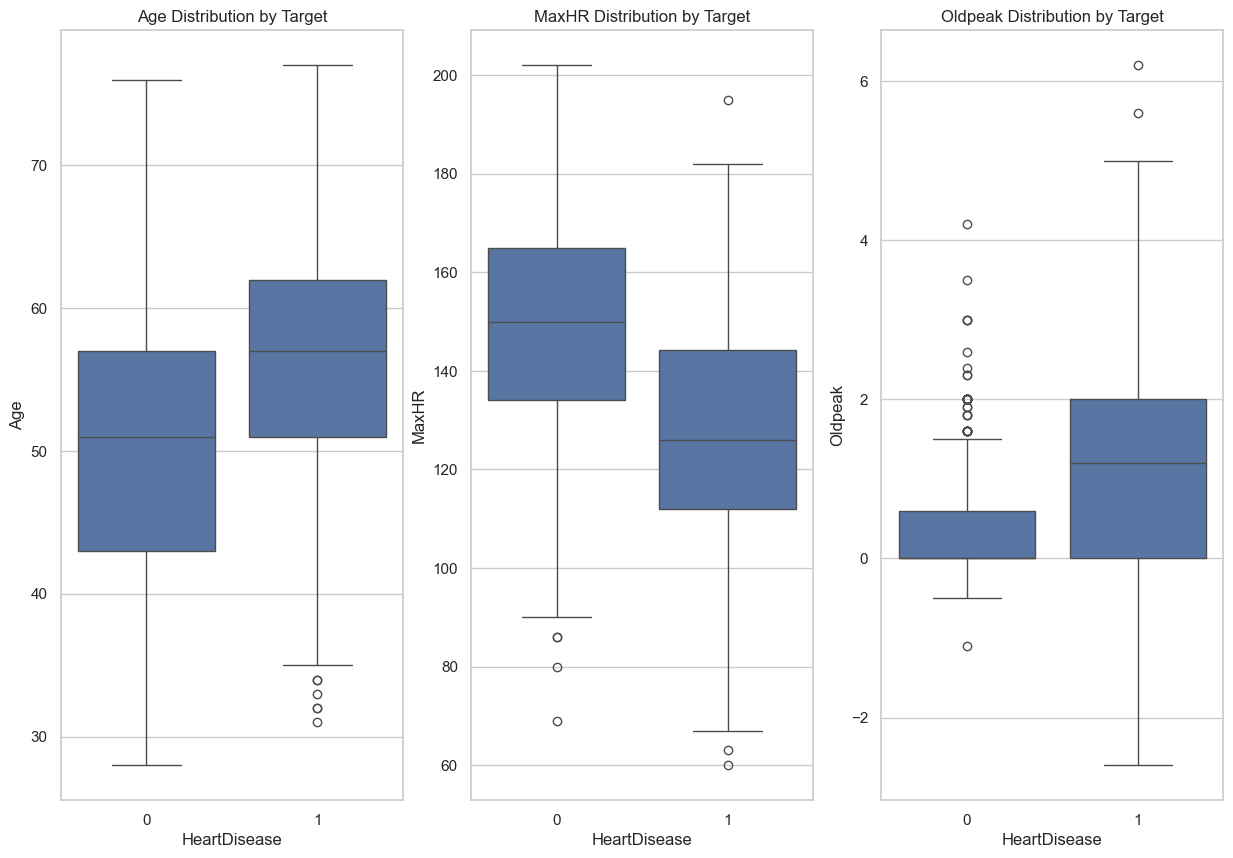

In [40]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(['Age', 'MaxHR', 'Oldpeak'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='HeartDisease', y=col, data=df)
    plt.title(f'{col} Distribution by Target')

Analysis: Patients with heart disease tend to have a lower MaxHR and higher Oldpeak values, confirming their roles as strong indicators.

## Multivariate Dimensionality Reduction

To see if the classes are separable, considering their tributaries, we will use PCA to reduce the dimensionality to 2 dimensions.

PCA (Principal Component Analysis) is a dimensionality reduction technique and helps us to reduce the number of features in a dataset while keeping the most important information. It changes complex datasets by transforming correlated features into a smaller set of uncorrelated components. It helps simplify the 12 dimensions into 2.

    In the PCA plot, we observe a non-linear nature of the data.

t-SNE is a tool to visualize high-dimensional data. It converts similarities between data points to joint probabilities and tries to minimize the Kullback-Leibler divergence between the joint probabilities of the low-dimensional embedding and the high-dimensional data.

    In the t-SNE diagram we can observe groupings/clusters based on the attributes of the dataset. A distinction between classes is also observed, so that classification methods can be applied to this dataset, being groups of patients with the same characteristics who were/are prone to cardiac arrest.

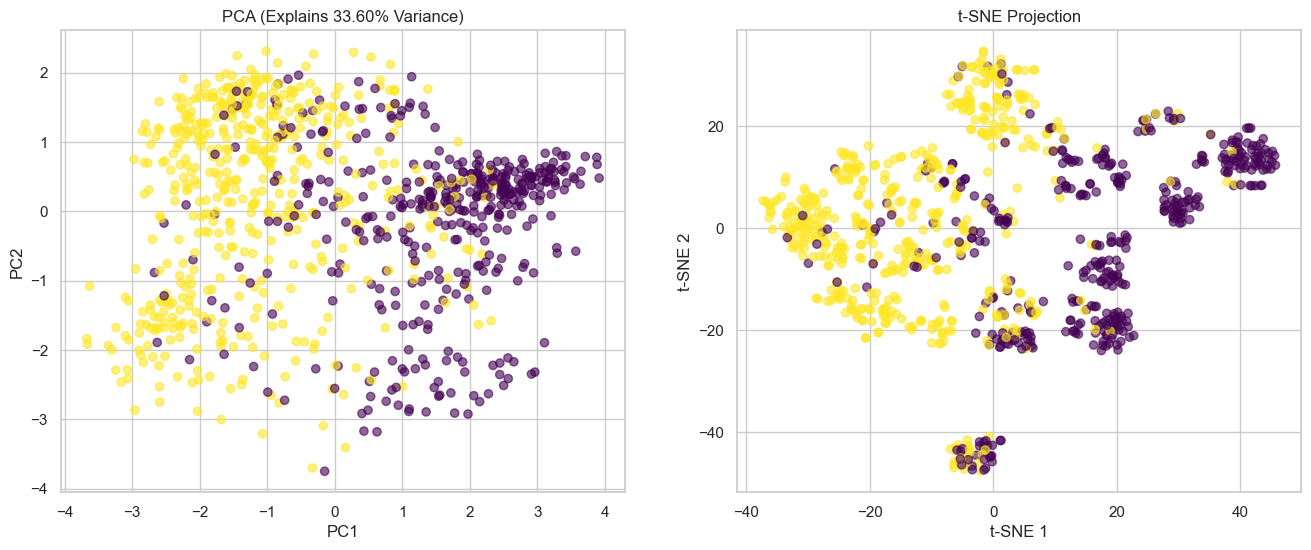

In [41]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('HeartDisease', axis=1)
X_scaled = StandardScaler().fit_transform(X)

# PCA (Linear Projection)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE (Non-linear Mapping)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot PCA and t-SNE
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=df['HeartDisease'], cmap='viridis', alpha=0.6)
ax1.set_title(f'PCA (Explains {pca.explained_variance_ratio_.sum():.2%} Variance)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['HeartDisease'], cmap='viridis', alpha=0.6)
ax2.set_title('t-SNE Projection')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

plt.show()

## Spearman Rank Correlation Analysis

Spearman's rank correlation coefficient is a number ranging from -1 to 1 that indicates how strongly two sets of ranks are correlated and it's more robust to outliers and non-normal distributions (like Oldpeak or Cholesterol)

Since the Oldpeak characteristic has a maximum score of 0.42 relative to the chance of having heart problems, it follows that the higher the Oldpeak, the more prone you are to heart problems. Also for increasing age keeping in mind the age-heart disease association

The negative correlation of -0.40 between MaxHR and HeartDisease means that a low level of MaxHR leads to the presence of Heart Disease.

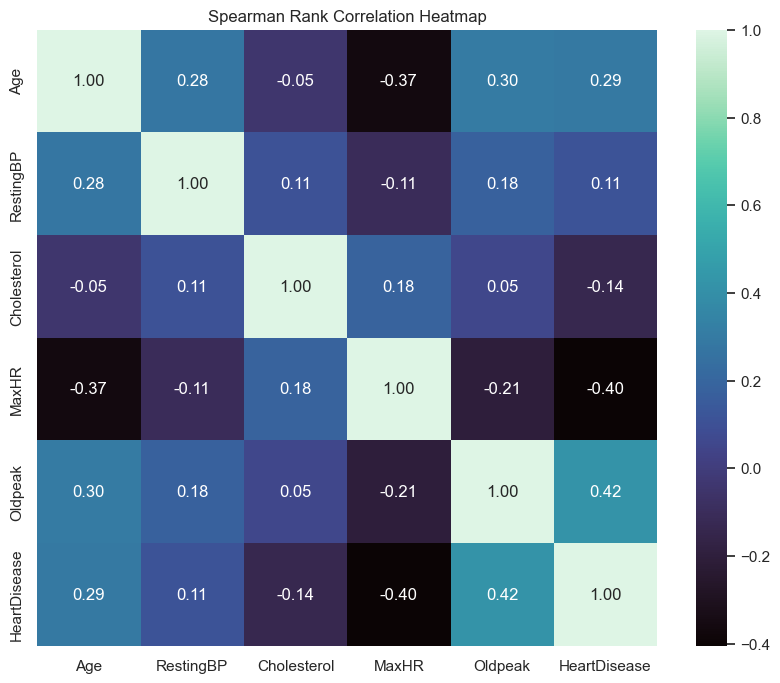

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Spearman Rank Correlation (Detects non-linear but monotonic relationships)
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']
spearman_corr = df[numerical_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='mako', fmt=".2f")
plt.title('Spearman Rank Correlation Heatmap')
plt.savefig('spearman_correlation.png')

## Correlation with Target (Sorted Ranking)

This is a focused bivariate analysis that directly ranks variables by their predictive "weight" relative to the target.

Method: We extract the HeartDisease column from the correlation matrix and sort it.

Insight: This provides an immediate visual hierarchy of importance. Positive bars (like Oldpeak and Age) indicate that higher values increase the risk, while negative bars (like MaxHR) indicate that higher values decrease the risk.

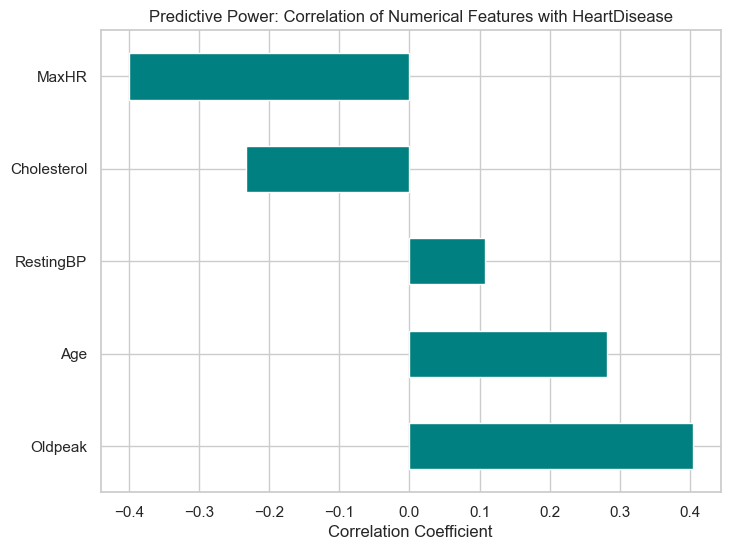

In [44]:
# 3. Correlation with Target (Sorted Bar Chart)
corr_with_target = df[numerical_cols].corr()['HeartDisease'].sort_values(ascending=False).drop('HeartDisease')

plt.figure(figsize=(8, 6))
corr_with_target.plot(kind='barh', color='teal')
plt.title('Predictive Power: Correlation of Numerical Features with HeartDisease')
plt.xlabel('Correlation Coefficient')
plt.savefig('corr_with_target.png')

## Robust Multivariate Correlation

A more robust approach uses one-hot encoding for categorical variables (Sex, ChestPainType, etc.) to see how specific categories (like Asymptomatic pain) correlate with the target

C:\Users\mariu\AppData\Local\Temp\ipykernel_13908\3683278597.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=heart_disease_corr.values, y=heart_disease_corr.index, palette='viridis')


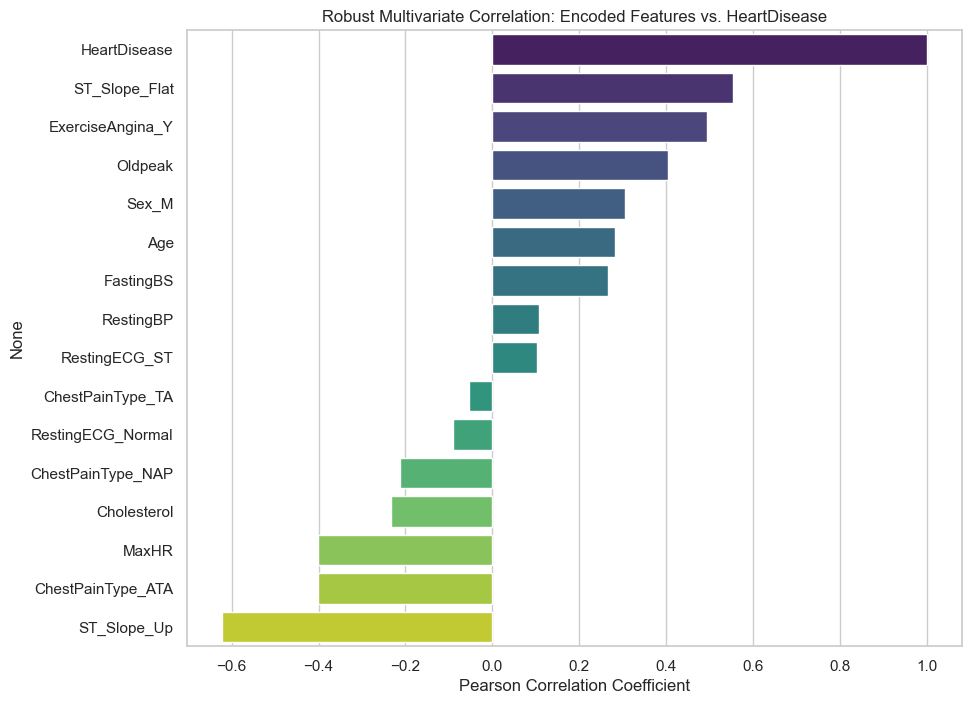

In [50]:
# 1. One-Hot Encoding for all categorical variables
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)

# 2. Compute Correlation with HeartDisease
plt.figure(figsize=(10, 8))
corr_matrix = df_encoded.corr()
heart_disease_corr = corr_matrix['HeartDisease'].sort_values(ascending=False)

# 3. Plotting the results
sns.barplot(x=heart_disease_corr.values, y=heart_disease_corr.index, palette='viridis')
plt.title('Robust Multivariate Correlation: Encoded Features vs. HeartDisease')
plt.xlabel('Pearson Correlation Coefficient')
plt.show()

## Numerical to numerical analysis

Combination of all numerical variables for a much detailed biriate analysis.

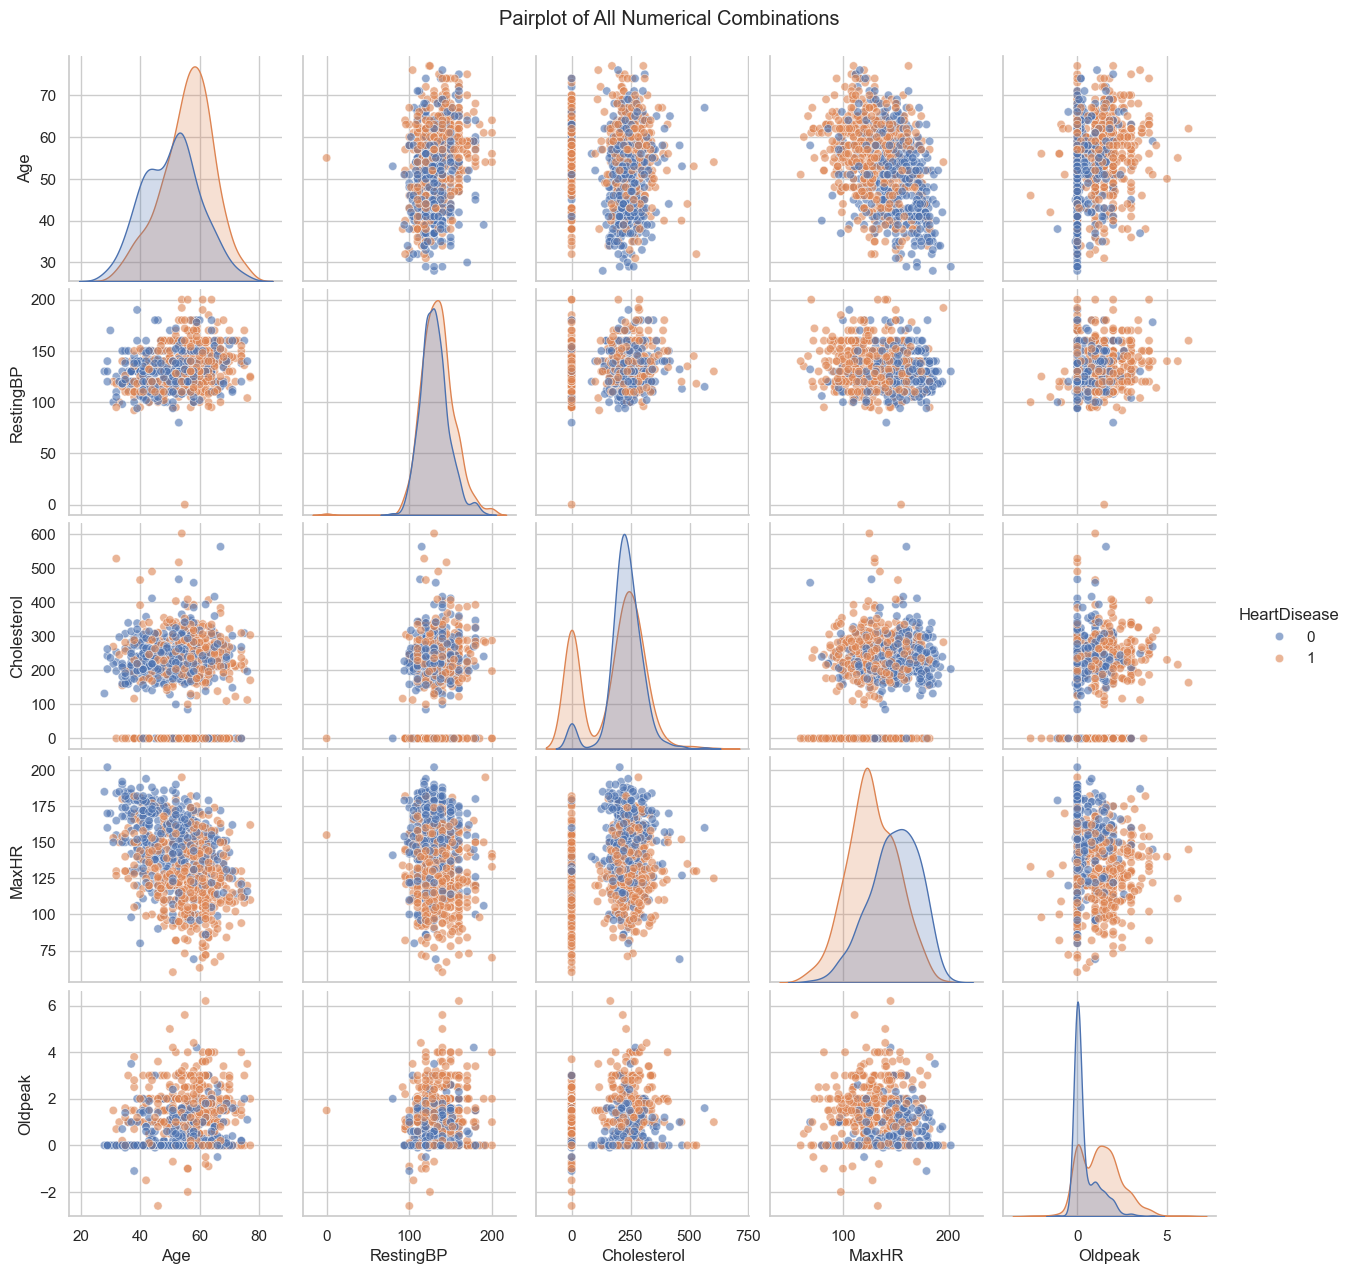

In [46]:
from itertools import combinations

numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

sns.set_theme(style="whitegrid")
g = sns.pairplot(df, vars=numerical_cols, hue='HeartDisease', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot of All Numerical Combinations', y=1.02)
plt.savefig('pairplot_all_numerical.png')

for x_col, y_col in combinations(numerical_cols, 2):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=x_col, y=y_col, hue='HeartDisease', alpha=0.6)
    plt.title(f'{x_col} vs {y_col} colored by Heart Disease')
    
    filename = f'{x_col.lower()}_vs_{y_col.lower()}.png'
    plt.savefig(filename)
    plt.close()

## Categorical to categorical analysis


RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

Considering the following plot, patients having ST-T wave abnormality and/or showing probable or definite left ventricular hypertrophy by Estes' criteria are more likely of having HD.

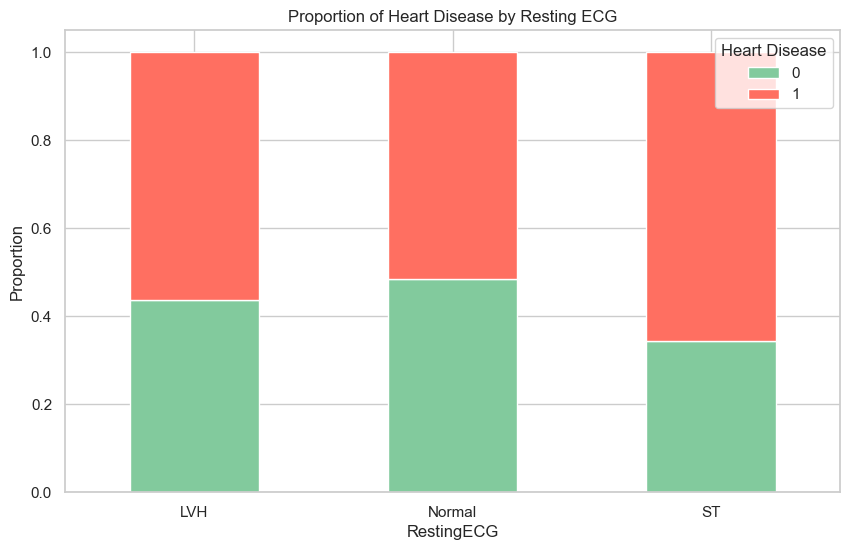

In [ ]:
ct = pd.crosstab(df['RestingECG'], df['HeartDisease'], normalize='index')
ct.plot(kind='bar', stacked=True, color=['#82ca9d','#ff6f61'], figsize=(10, 6))
plt.title('Proportion of Heart Disease by Resting ECG')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Heart Disease')
plt.savefig('restingecg_vs_heartdisease_stacked.png')

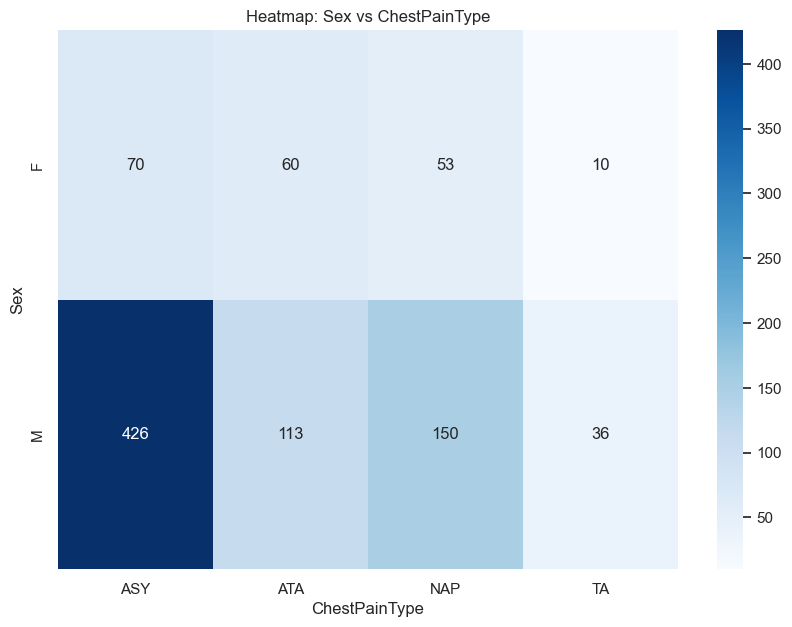

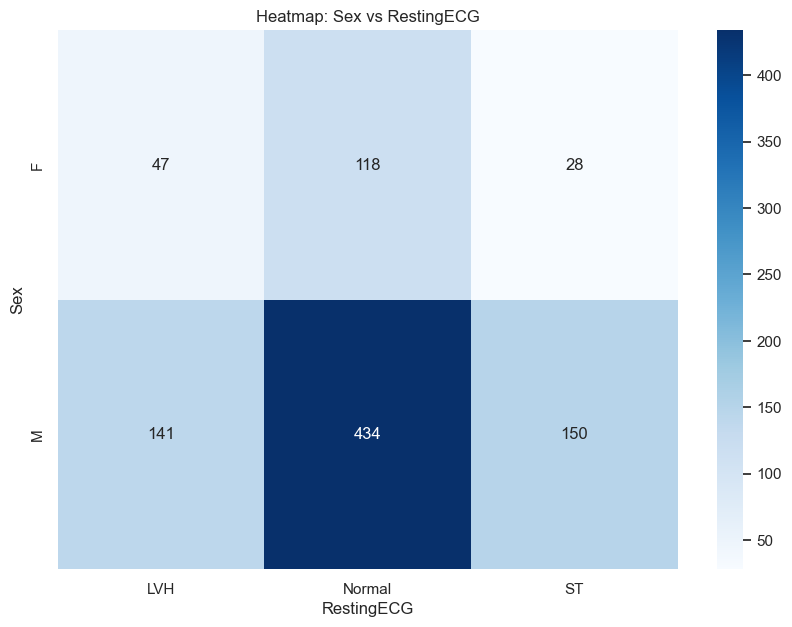

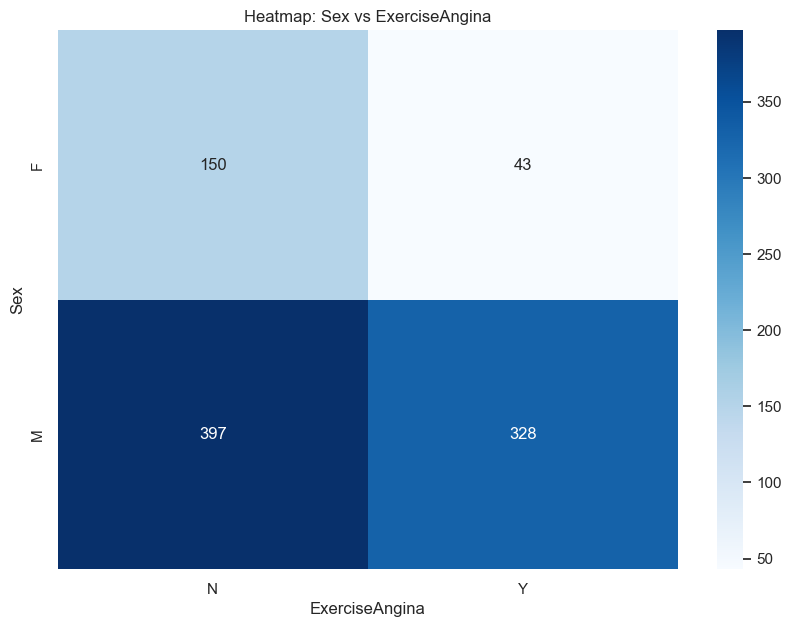

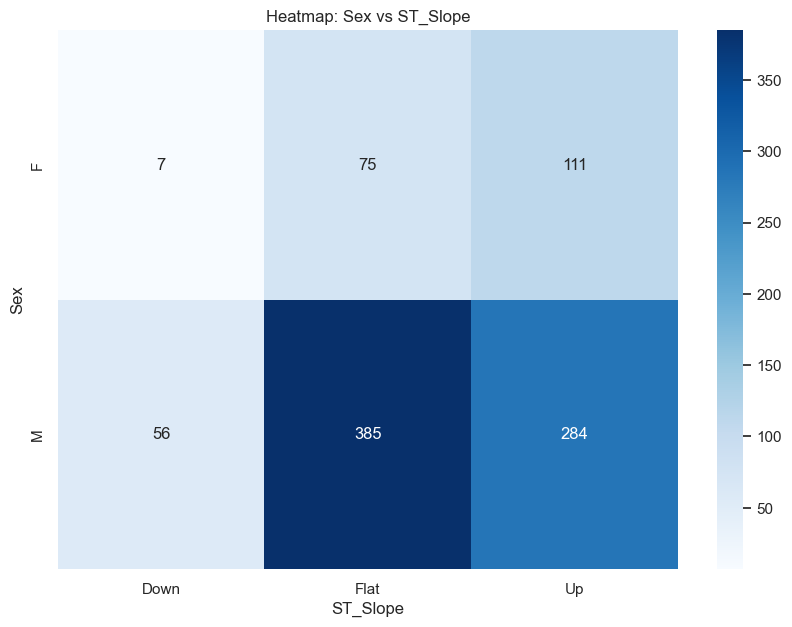

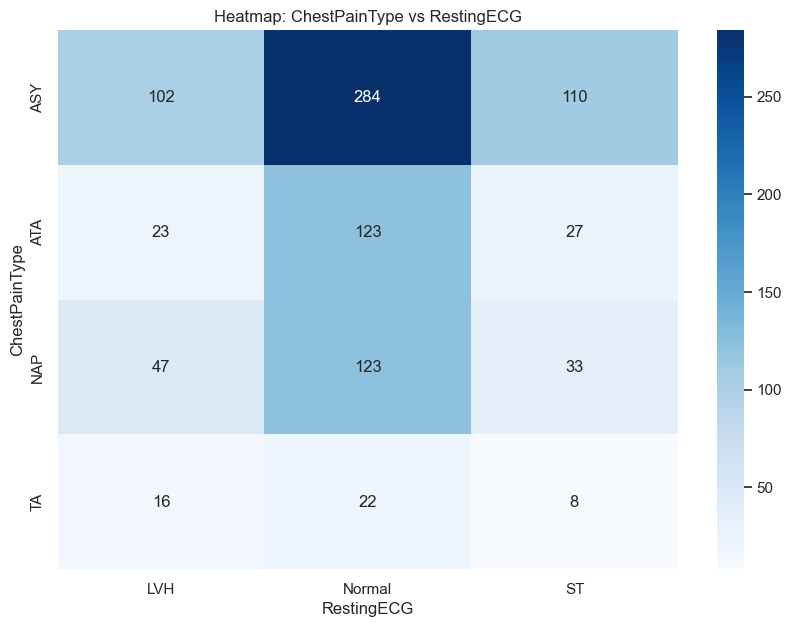

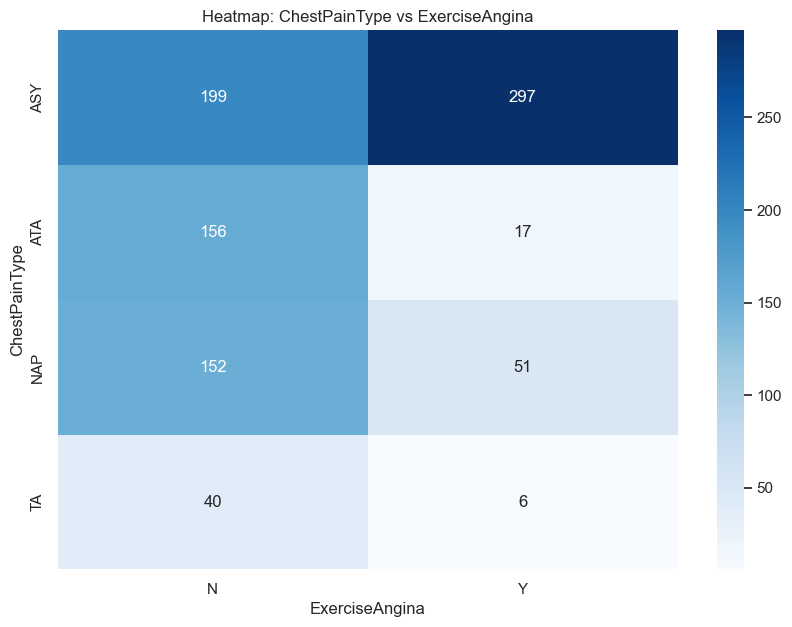

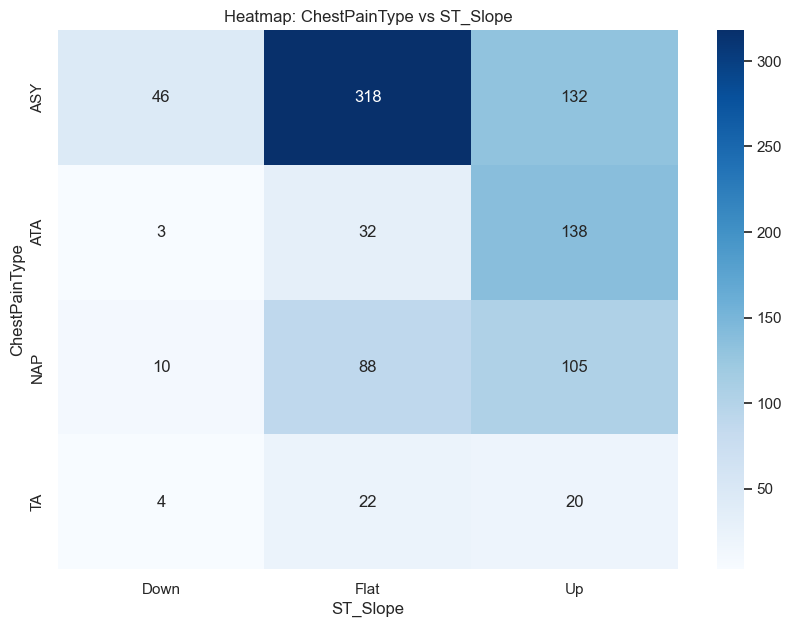

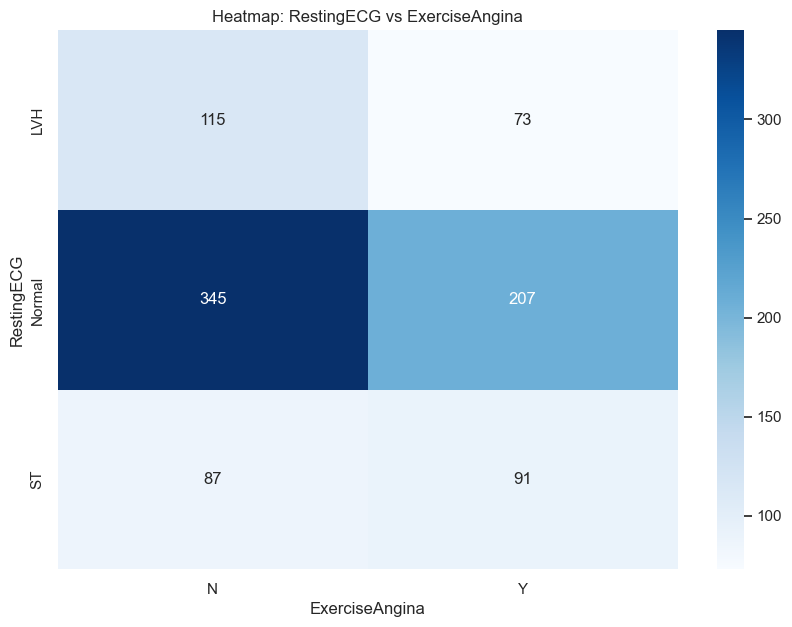

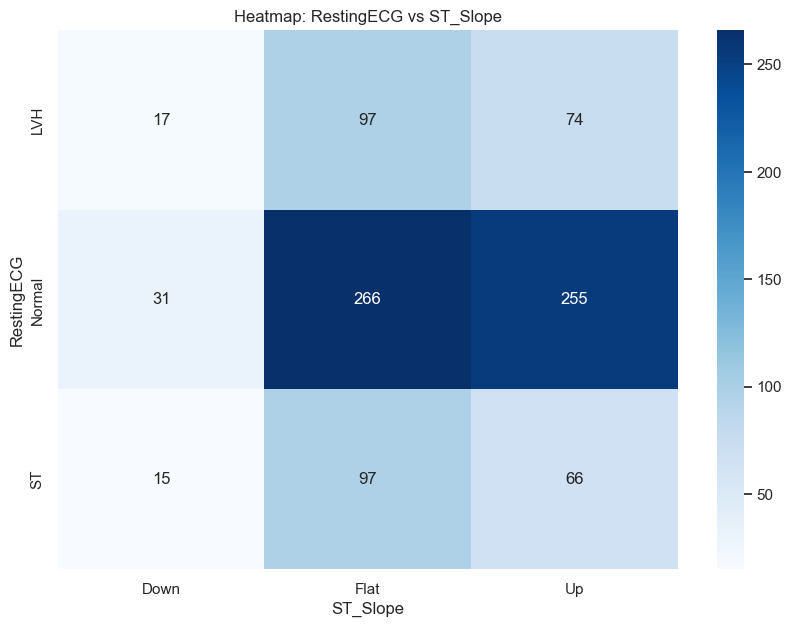

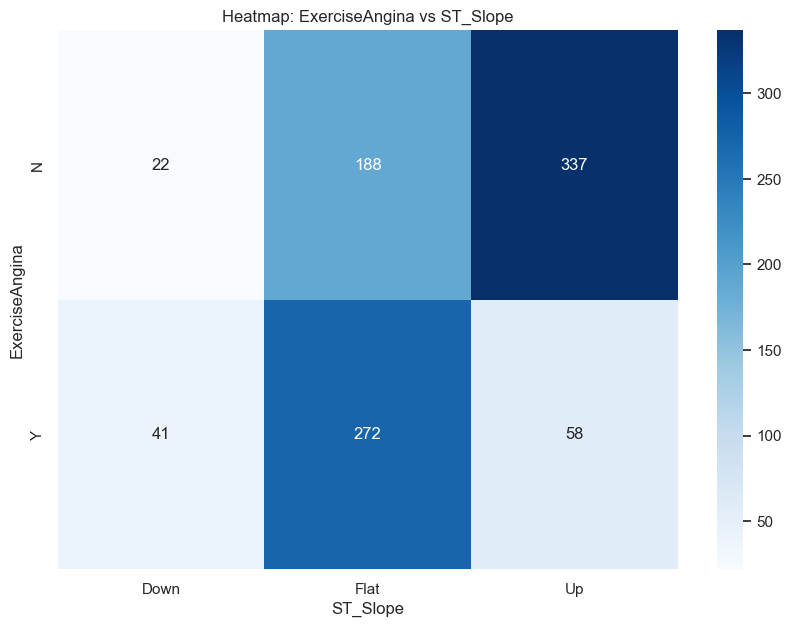

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# Define your categorical columns
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

sns.set_theme(style="white")

# Iterating through every combination of 2 categorical variables
for col1, col2 in combinations(categorical_cols, 2):
    plt.figure(figsize=(10, 7))
    
    # Create the contingency table
    contingency = pd.crosstab(df[col1], df[col2])
    
    # Plot the heatmap
    sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', cbar=True)
    
    plt.title(f'Heatmap: {col1} vs {col2}')
    
    filename = f'heatmap_{col1.lower()}_vs_{col2.lower()}.png'
    plt.savefig(filename)
    plt.show()

## Multivariate Analysis

This implementation discovers how two variables interact to increase risk. For example, does the combination of low MaxHR and high Oldpeak drastically change the heart disease probability?

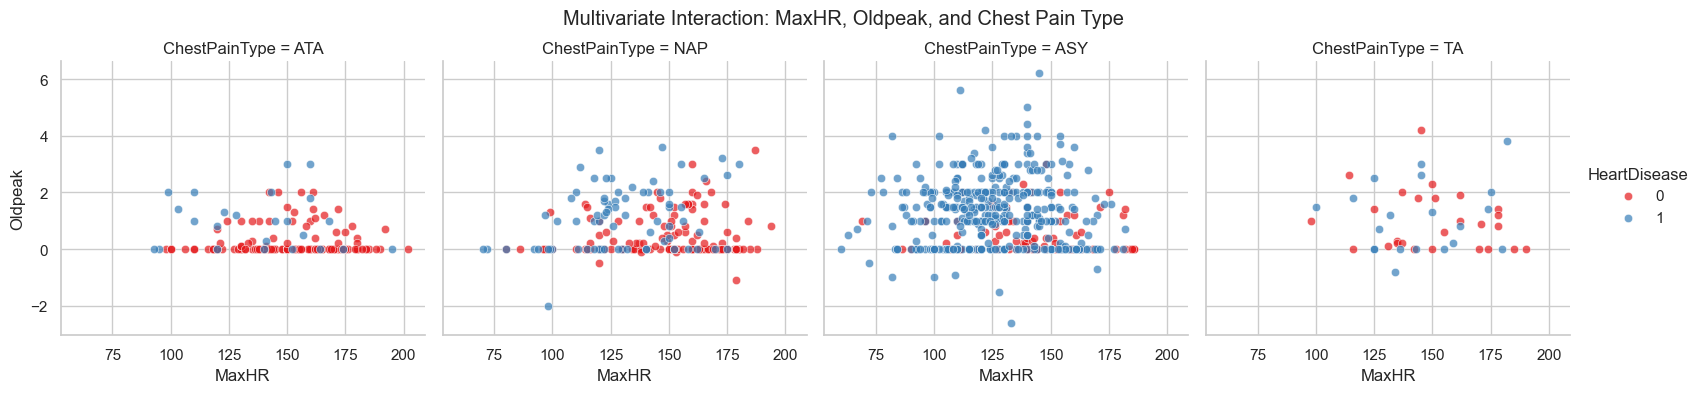

In [48]:
# Facetted Interaction: MaxHR vs Oldpeak by ChestPainType
g = sns.FacetGrid(df, col="ChestPainType", hue="HeartDisease", height=4, palette='Set1')
g.map(sns.scatterplot, "MaxHR", "Oldpeak", alpha=.7)
g.add_legend()
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Multivariate Interaction: MaxHR, Oldpeak, and Chest Pain Type')
plt.show()